# SAAM Project - Pacific Region

Sustainable & Active Asset Management - portfolio construction with carbon constraints.

This notebook is fully self-contained: it reads the project input files directly from `data/` and produces every table in `outputs/tables/` and every figure in `outputs/figures/`. It does **not** import anything from `src/`. The methodology follows the project PDF and the existing src reference code (MVP-construction, 05_part3.py, 06_part4.py).

Structure:
1. Setup
2. Short introduction
3. Data loading and cleaning
4. Part 1 - Minimum-Variance Portfolio (P_mv)
5. Part 2 - Value-Weighted benchmark (P_vw)
6. Part 3 - 50% carbon-footprint reduction (P_mv_50, P_vw_50)
7. Part 4 - Net-Zero trajectory (P_vw_NZ)
8. Final performance summary
9. Short conclusion

## 1. Setup

Imports, robust pathlib paths, methodology constants, and output folders.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# project paths
ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
DATA = ROOT / "data"
RAW = DATA / "raw"
PROCESSED = DATA / "processed"
OUTPUTS = ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"
for d in (OUTPUTS, TABLES, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

# methodology constants (identical to the src reference)
YEAR_FIRST = 2013      # first allocation year (decision at end of Y)
YEAR_LAST = 2024       # last allocation year -> implementation Y+1 = 2025
PERF_START = 2014      # first implementation year (inclusive)
PERF_END = 2025        # last implementation year (inclusive)
ESTIM_MONTHS = 120     # 10-year rolling estimation window
MIN_OBS = 36           # >= 3 years of returns in the window
STALE_THRESHOLD = 0.50 # <= 50% zero returns in the window
RIDGE_EPS = 1e-6       # ridge added to Sigma
THETA_NZ = 0.10        # 10% per year carbon decay (Part 4)
CARBON_SCOPE = "scope1" # assigned climate strategy for this group

pd.options.display.float_format = "{:,.4f}".format
print("Setup OK. ROOT =", ROOT)

def file_inventory(folder):
    """Return a notebook-friendly inventory of files under a folder."""
    rows = []
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            rows.append({
                "folder": str(path.parent.relative_to(ROOT)),
                "file": path.name,
                "relative_path": str(path.relative_to(ROOT)),
                "size_kb": path.stat().st_size / 1024.0,
            })
    return pd.DataFrame(rows)

input_files = pd.concat([file_inventory(RAW), file_inventory(PROCESSED)], ignore_index=True)
print("Input files available to this notebook:")
display(input_files)

Matplotlib is building the font cache; this may take a moment.


Setup OK. ROOT = /Users/yazidabaroudi/SAAM-Project-1
Input files available to this notebook:


,folder,file,relative_path,size_kb
0,data/raw,DS_CO2_SCOPE_1_Y_2025.xlsx,data/raw/DS_CO2_SCOPE_1_Y_2025.xlsx,290.4463
1,data/raw,DS_MV_T_USD_M.csv,data/raw/DS_MV_T_USD_M.csv,"6,154.5371"
2,data/raw,DS_MV_T_USD_Y.csv,data/raw/DS_MV_T_USD_Y.csv,592.2803
3,data/raw,DS_RI_T_USD_M_2025.xlsx,data/raw/DS_RI_T_USD_M_2025.xlsx,"5,684.3359"
4,data/raw,Risk_Free_Rate_2025.xlsx,data/raw/Risk_Free_Rate_2025.xlsx,14.2412
5,data/processed,Clean_CO2_Scope1_Pacific.csv,data/processed/Clean_CO2_Scope1_Pacific.csv,65.6357
6,data/processed,Clean_Prices_Pacific.csv,data/processed/Clean_Prices_Pacific.csv,904.7061
7,data/processed,Clean_Revenues_Pacific.csv,data/processed/Clean_Revenues_Pacific.csv,146.1826
8,data/processed,Pacific_Universe.csv,data/processed/Pacific_Universe.csv,18.0195
9,data/processed,Returns.csv,data/processed/Returns.csv,"3,039.3818"


## 2. Short introduction

We build five portfolios on the Pacific equity universe and compare their financial **and** carbon performance over 2014-2025:

- **P_vw**: market-cap weighted benchmark, monthly rebalanced (Section 2.3).
- **P_mv**: long-only minimum-variance portfolio, annually rebalanced, intra-year drift (Section 2.2).
- **P_mv_50**: minimum variance with carbon footprint capped at 50% of P_mv (Section 3.2).
- **P_vw_50**: tracking-error minimisation vs P_vw with the same 50% CF cap (Section 3.3).
- **P_vw_NZ**: tracking-error minimisation vs P_vw with a declining Net-Zero cap, -10% per year from the 2013 anchor (Section 4).

Carbon metrics:
- WACI = $\sum_i w_i\, \text{CI}_i$ with $\text{CI}_i = E_i / (\text{Rev}_i / 1000)$ (tCO2e per M$ revenue).
- Carbon Footprint CF = $\sum_i w_i \, (E_i / \text{Cap}_i)$ (tCO2e per M$ invested).

Why it matters: investors want low risk and exposure to the climate transition. Comparing constrained portfolios to unconstrained ones shows the financial *cost*, or *absence of cost*, of decarbonisation.

## 3. Data loading and cleaning

We read the Pacific input panels: prices, emissions (Scope 1), revenues, market cap (annual + monthly), risk-free rate. PDF Section 2.1 cleaning rules are applied to prices:
- price < 0.5 -> NaN,
- internal gaps -> forward fill,
- trailing NaNs (delisting) -> 0 so the delisting-month return = -100%.

Annual panels (CO2, revenues, cap_y) are forward-filled to plug rare missing entries.

In [2]:
# generic loader for Datastream-style wide CSVs (ISIN x periods)
def read_wide(path, date_columns):
    df = pd.read_csv(path)
    df = df[df["ISIN"].notna()].copy()
    df["ISIN"] = df["ISIN"].astype(str)
    df = df.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")
    if date_columns:
        df.columns = pd.to_datetime(df.columns).normalize()
    else:
        df.columns = df.columns.astype(int)
    return df

# read panels (already cleaned at ingest stage)
prices_wide = read_wide(PROCESSED / "Clean_Prices_Pacific.csv", date_columns=True)
emissions = read_wide(PROCESSED / "Clean_CO2_Scope1_Pacific.csv", date_columns=False).sort_index(axis=1).ffill(axis=1)
revenues = read_wide(PROCESSED / "Clean_Revenues_Pacific.csv", date_columns=False).sort_index(axis=1).ffill(axis=1)

static = pd.read_csv(PROCESSED / "Pacific_Universe.csv")
name_col = "NAME" if "NAME" in static.columns else "Name"
names = static.set_index("ISIN")[name_col].astype(str)
countries = static.set_index("ISIN")["Country"].astype(str)
pacific = set(static["ISIN"].astype(str))

# market cap (Y for eligibility/CF, M for the VW benchmark)
cap_y = read_wide(RAW / "DS_MV_T_USD_Y.csv", date_columns=False).sort_index(axis=1).ffill(axis=1)
cap_y = cap_y.loc[cap_y.index.intersection(pacific)]
cap_m = read_wide(RAW / "DS_MV_T_USD_M.csv", date_columns=True).T.sort_index()
cap_m = cap_m.loc[:, cap_m.columns.intersection(list(pacific))]

print("Loaded:", "prices", prices_wide.shape, "| emissions", emissions.shape,
      "| revenues", revenues.shape, "| cap_y", cap_y.shape, "| cap_m", cap_m.shape)

Loaded: prices (513, 314) | emissions (513, 27) | revenues (513, 27) | cap_y (513, 27) | cap_m (314, 513)


In [3]:
# price cleaning (Section 2.1)
prices = prices_wide.T.sort_index()                # dates x ISIN
prices = prices.where(prices >= 0.5)               # <0.5 -> NaN
has_val = prices.notna().astype(np.int8)
ahead = has_val.iloc[::-1].cumsum(axis=0).iloc[::-1]
trailing = prices.isna() & (ahead == 0)            # delisting
prices = prices.ffill(axis=0)
prices[trailing] = 0.0

# monthly returns (delisting handled as -100%)
prev = prices.shift(1)
rets = prices / prev.replace(0.0, np.nan) - 1.0
rets[(prices == 0.0) & (prev > 0.0)] = -1.0
rets = rets.replace([np.inf, -np.inf], np.nan)

# align all panels on the common ISINs
common = (prices.columns
          .intersection(emissions.index)
          .intersection(revenues.index)
          .intersection(cap_y.index))
prices = prices[common]
rets = rets[common]
emissions = emissions.loc[common]
revenues = revenues.loc[common]
cap_y = cap_y.loc[common]
cap_m = cap_m.loc[:, cap_m.columns.intersection(common)]

# Pacific monthly RF (period column = YYYYMM int, RF in % per month)
rf_raw = pd.read_csv(PROCESSED / "rf_rate.csv")
rf_raw.columns = ["period", "rf"]
rf_raw = rf_raw.dropna()
rf_dates = pd.to_datetime(rf_raw["period"].astype(int).astype(str).str.zfill(6),
                          format="%Y%m") + pd.offsets.MonthEnd(0)
rf_monthly = pd.Series(rf_raw["rf"].to_numpy() / 100.0,
                       index=rf_dates, name="rf").sort_index()

rf_timeline = rf_monthly.loc["2013-12-31":"2024-12-31"].rename("monthly_rf_decimal").to_frame()
rf_timeline["monthly_rf_percent"] = rf_timeline["monthly_rf_decimal"] * 100.0
rf_timeline.index.name = "date"
rf_timeline.to_csv(TABLES / "risk_free_rate_dec2013_dec2024.csv")

print(f"Aligned universe: {len(common)} ISINs | rets {rets.shape} | rf_monthly {rf_monthly.shape}")
print(f"Risk-free timeline Dec 2013-Dec 2024: {len(rf_timeline)} months; saved to outputs/tables/risk_free_rate_dec2013_dec2024.csv")
display(rf_timeline)

Aligned universe: 513 ISINs | rets (314, 513) | rf_monthly (312,)
Risk-free timeline Dec 2013-Dec 2024: 133 months; saved to outputs/tables/risk_free_rate_dec2013_dec2024.csv


,monthly_rf_decimal,monthly_rf_percent
date,,
2013-12-31,0.0000,0.0000
2014-01-31,0.0000,0.0000
2014-02-28,0.0000,0.0000
2014-03-31,0.0000,0.0000
2014-04-30,0.0000,0.0000
...,...,...
2024-08-31,0.0048,0.4800
2024-09-30,0.0040,0.4000
2024-10-31,0.0039,0.3900


### Helper functions

Three reusable helpers (faithful to the src code):
- `build_year_inputs(Y)`: eligible universe, complete-case covariance, value weights, carbon vectors at end-of-Y.
- `solve_qp(...)`: long-only QP (variance or tracking error) with an optional carbon-footprint cap, SLSQP with analytic gradients and the same warm-start trick used in src so the cap is always feasible.
- `simulate_year(weights, returns)`: monthly portfolio returns over the implementation year, weights drift (no intra-year rebalancing).
- `vw_monthly_rebalanced_year(Y+1, isins)`: official Section 2.3 monthly value-weighted benchmark for the same eligible universe used in the annual optimisation.

In [4]:
def build_year_inputs(year):
    est_start = pd.Timestamp(year - 9, 1, 1)
    est_end = pd.Timestamp(year, 12, 31)
    oos_start = pd.Timestamp(year + 1, 1, 1)
    oos_end = pd.Timestamp(year + 1, 12, 31)

    rets_win = rets.loc[est_start:est_end]
    rets_oos = rets.loc[oos_start:oos_end]

    obs = rets_win.count()
    zero_ratio = (rets_win == 0.0).sum() / obs.replace(0, np.nan)
    last_px_ok = prices.loc[:est_end].iloc[-1].gt(0)

    # eligibility filters: carbon, revenue, cap > 0 at Y; price > 0; >=36 obs; <=50% zeros
    eligible = (
        emissions[year].notna()
        & revenues[year].gt(0)
        & cap_y[year].gt(0)
        & last_px_ok.reindex(emissions.index).fillna(False)
        & obs.reindex(emissions.index).ge(MIN_OBS).fillna(False)
        & zero_ratio.reindex(emissions.index).le(STALE_THRESHOLD).fillna(False)
    )
    isins = sorted(eligible[eligible].index.intersection(rets_oos.columns))
    if not isins:
        raise RuntimeError(f"No eligible firms for year {year}")

    rets_est = rets_win[isins].iloc[-ESTIM_MONTHS:]
    complete = rets_est.dropna(how="any")
    if len(complete) < MIN_OBS:
        filled = rets_est.apply(lambda s: s.fillna(s.mean())).fillna(0.0)
        cov = np.cov(filled.to_numpy(), rowvar=False, ddof=0)
    else:
        cov = np.cov(complete.to_numpy(), rowvar=False, ddof=0)
    cov = (cov + cov.T) / 2.0 + RIDGE_EPS * np.eye(len(isins))

    cap_yi = cap_y.loc[isins, year].astype(float)
    emi_yi = emissions.loc[isins, year].astype(float)
    rev_yi = revenues.loc[isins, year].astype(float)
    return {
        "year": year, "isins": isins,
        "rets_oos": rets_oos[isins],
        "cov": cov,
        "ci": emi_yi / (rev_yi / 1000.0),       # tCO2e per M$ revenue
        "cf_per_w": emi_yi / cap_yi,            # tCO2e per M$ invested (per unit weight)
        "w_vw": (cap_yi / cap_yi.sum()).to_numpy(),
    }

In [5]:
def solve_qp(cov, objective="variance", benchmark=None, carbon=None, carbon_limit=None):
    """Long-only QP. SLSQP with analytic gradients.
    min w'Sigma w  (variance)  OR  min (w-b)'Sigma(w-b)  (tracking_error)
    s.t. sum(w)=1, 0<=w<=1, optional carbon.w <= carbon_limit."""
    n = cov.shape[0]
    bench = np.full(n, 1.0 / n) if benchmark is None else np.asarray(benchmark, float)
    x0 = bench.copy() if objective == "tracking_error" else np.full(n, 1.0 / n)

    # if warm-start violates the cap, pull it towards the lowest-carbon asset
    if carbon is not None and carbon_limit is not None and float(x0 @ carbon) > carbon_limit:
        unit = np.zeros(n); unit[int(np.argmin(carbon))] = 1.0
        base, low = float(x0 @ carbon), float(unit @ carbon)
        if low > carbon_limit:
            x0 = unit
        else:
            alpha = float(np.clip((base - carbon_limit) / max(base - low, 1e-12) + 1e-3, 0.0, 1.0))
            x0 = (1.0 - alpha) * x0 + alpha * unit

    if objective == "variance":
        fun = lambda w: float(w @ cov @ w)
        jac = lambda w: 2.0 * cov @ w
    else:
        b = bench
        fun = lambda w: float((w - b) @ cov @ (w - b))
        jac = lambda w: 2.0 * cov @ (w - b)

    cons = [{"type": "eq", "fun": lambda w: float(w.sum() - 1.0),
             "jac": lambda w: np.ones_like(w)}]
    if carbon is not None and carbon_limit is not None:
        c = np.asarray(carbon, float); L = float(carbon_limit)
        cons.append({"type": "ineq",
                     "fun": lambda w, c=c, L=L: float(L - w @ c),
                     "jac": lambda w, c=c: -c})

    # ftol=1e-8 / maxiter=200 is plenty for the SAAM QPs and ~3x faster than 1e-10
    res = minimize(fun, x0, jac=jac, method="SLSQP", bounds=[(0.0, 1.0)] * n,
                   constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-8, "disp": False})
    w = np.clip(res.x, 0.0, None)
    if w.sum() > 0:
        w = w / w.sum()
    ok = bool(res.success)
    if carbon is not None and carbon_limit is not None:
        ok = ok and float(w @ np.asarray(carbon, float)) <= carbon_limit + 1e-6
    return w, ok, str(res.message)


def simulate_year(weights, rets_oos):
    """Monthly returns of a portfolio with drifting weights over the implementation year."""
    w = weights.copy()
    out = {}
    for date, row in rets_oos.fillna(0.0).iterrows():
        r = row.to_numpy(float)
        rp = float(w @ r)
        out[date] = rp
        if 1.0 + rp <= 0.0:
            break
        w = np.clip(w * (1.0 + r) / (1.0 + rp), 0.0, None)
        if w.sum() > 0:
            w = w / w.sum()
    return pd.Series(out, dtype=float)


def vw_monthly_rebalanced():
    """Broad Section 2.3 VW benchmark using previous-period weights over all aligned firms.
    Kept only as a broad-universe diagnostic; report comparisons use vw_monthly_rebalanced_year."""
    cap = cap_m.reindex(index=rets.index, columns=rets.columns)
    w = cap.div(cap.sum(axis=1), axis=0).shift(1)
    return (w * rets).sum(axis=1, min_count=1)


def vw_monthly_rebalanced_year(implementation_year, isins):
    """Official project VW benchmark for one implementation year and eligible universe.

    The benchmark uses previous-month market-cap weights and the same ISIN set as the
    annual optimisation decided at end-of-year Y = implementation_year - 1.
    """
    start = f"{implementation_year}-01-01"
    end = f"{implementation_year}-12-31"

    r = rets.loc[start:end, isins]
    cap_aligned = cap_m.reindex(index=rets.index, columns=isins)
    w_prev = cap_aligned.shift(1).loc[start:end]

    valid = r.notna() & w_prev.notna()
    w_prev = w_prev.where(valid)

    # Renormalise each month over firms with both a return and previous-month cap.
    w_prev = w_prev.div(w_prev.sum(axis=1), axis=0)

    return (w_prev * r.fillna(0.0)).sum(axis=1, min_count=1)


def concentration_stats(w):
    """Simple annual concentration diagnostics for a portfolio weight vector."""
    w = np.asarray(w, dtype=float)
    hhi = float(np.sum(w ** 2))
    effective_n = float(1.0 / hhi) if hhi > 0 else np.nan
    n_positive = int(np.sum(w > 1e-6))
    max_weight = float(np.max(w)) if len(w) else np.nan
    return hhi, effective_n, n_positive, max_weight


### Annual loop: solve every portfolio in a single pass

We loop once over Y = 2013..2024 and solve all five portfolios on the *same* Sigma_Y. This avoids the duplicate work that the src code did (Parts 3 and 4 ran two separate annual passes). Inside the loop we collect:
- monthly returns for `vw` / `vw_drift` / `mv` / `mv_50` / `vw_50` / `vw_nz`,
- `vw`, the official monthly-rebalanced value-weighted benchmark built on the same yearly eligible universe,
- `vw_drift`, the annual value-weighted allocation held through the implementation year with intra-year drift,
- weights at the start of each implementation year (positive weights only),
- annual carbon metrics (CF, WACI) and constraint slack,
- ex-ante tracking error vs the annual VW allocation vector,
- top-10 WACI / CF contributors of the annual VW allocation.

In [6]:
# anchor footprint CF(P_vw) at Y0 = YEAR_FIRST (used for the NZ cap path)
yi_anchor = build_year_inputs(YEAR_FIRST)
cf_vw_anchor = float(yi_anchor["w_vw"] @ yi_anchor["cf_per_w"].to_numpy())
print(f"Anchor CF(P_vw)_{YEAR_FIRST} = {cf_vw_anchor:.4f} tCO2e/M$")

labels = ["vw", "vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]
month_segs = {lab: [] for lab in labels}
annual_rows, weight_rows, te_rows, slack_rows, concentration_rows = [], [], [], [], []
waci_top_rows, cf_top_rows, path_rows = [], [], []

for year in range(YEAR_FIRST, YEAR_LAST + 1):
    yi = build_year_inputs(year)
    carbon = yi["cf_per_w"].to_numpy()
    ci_vec = yi["ci"].to_numpy()
    w_vw = yi["w_vw"]
    cf_vw = float(w_vw @ carbon)

    # Official Section 2.3 monthly VW benchmark for this implementation year,
    # restricted to the same eligible universe as the annual optimisation.
    vw_series = vw_monthly_rebalanced_year(year + 1, yi["isins"])
    month_segs["vw"].append(vw_series)

    # solve four QPs on the same Sigma_Y
    w_mv,   ok_mv,   msg_mv   = solve_qp(yi["cov"], "variance")
    cf_mv = float(w_mv @ carbon)
    w_mv50, ok_mv50, msg_mv50 = solve_qp(yi["cov"], "variance",
                                          carbon=carbon, carbon_limit=0.5 * cf_mv)
    w_vw50, ok_vw50, msg_vw50 = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=0.5 * cf_vw)
    cap_nz = ((1.0 - THETA_NZ) ** (year - YEAR_FIRST + 1)) * cf_vw_anchor
    w_nz,   ok_nz,   msg_nz   = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=cap_nz)

    portfolios = {
        "vw_drift": (w_vw,   True,    "annual VW allocation with drift", cf_vw),
        "mv":       (w_mv,   ok_mv,   msg_mv,                         np.nan),
        "mv_50":    (w_mv50, ok_mv50, msg_mv50,                       0.5 * cf_mv),
        "vw_50":    (w_vw50, ok_vw50, msg_vw50,                       0.5 * cf_vw),
        "vw_nz":    (w_nz,   ok_nz,   msg_nz,                         cap_nz),
    }

    # simulate implementation year for each annual-allocation portfolio
    for lab, (w, ok, msg, cap_lim) in portfolios.items():
        s = simulate_year(w, yi["rets_oos"])
        month_segs[lab].append(s)

        cf = float(w @ carbon)
        wc = float(w @ ci_vec)
        cap_val = None if (isinstance(cap_lim, float) and np.isnan(cap_lim)) else cap_lim
        annual_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "n_assets": len(yi["isins"]),
            "waci_tco2e_per_musd_revenue": wc,
            "carbon_footprint_tco2e_per_musd_invested": cf,
            "carbon_limit": cap_lim,
            "optimization_success": bool(ok), "optimization_message": msg,
        })
        slack_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "carbon_footprint": cf,
            "carbon_limit": cap_val if cap_val is not None else np.nan,
            "slack": (cap_val - cf) if cap_val is not None else np.nan,
            "satisfied_within_1e-6": bool(cap_val is None or (cap_val - cf) >= -1e-6),
            "optimization_success": bool(ok), "optimization_message": msg,
        })

        hhi, effective_n, n_positive, max_weight = concentration_stats(w)
        concentration_rows.append({
            "year": year,
            "implementation_year": year + 1,
            "portfolio": lab,
            "hhi": hhi,
            "effective_number_of_holdings": effective_n,
            "number_positive_weights": n_positive,
            "max_weight": max_weight,
        })

        active = pd.Series(w, index=yi["isins"])
        for isin, weight in active[active > 1e-6].sort_values(ascending=False).items():
            weight_rows.append({
                "year": year, "portfolio": lab, "ISIN": isin,
                "name": names.get(isin, ""), "country": countries.get(isin, ""),
                "weight": float(weight),
                "ci": float(yi["ci"].get(isin, np.nan)),
                "cf_per_weight": float(yi["cf_per_w"].get(isin, np.nan)),
            })

        diff_w = w - w_vw
        ex_ante = float(np.sqrt(max(diff_w @ yi["cov"] @ diff_w, 0.0) * 12.0))
        te_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "ex_ante_tracking_error_annual": ex_ante,
            "ex_post_tracking_error_vs_monthly_vw_annual": np.nan,
            "ex_post_tracking_error_vs_vw_drift_annual": np.nan,
        })

    # top-10 WACI / CF contributors using annual VW weights on the eligible universe
    contrib = pd.DataFrame({
        "ISIN": yi["isins"],
        "name": names.reindex(yi["isins"]).to_numpy(),
        "country": countries.reindex(yi["isins"]).to_numpy(),
        "ci_tco2e_per_musd_revenue": ci_vec,
        "cf_per_weight_tco2e_per_musd_invested": carbon,
        "vw_weight": w_vw,
        "vw_waci_contribution": w_vw * ci_vec,
        "vw_cf_contribution": w_vw * carbon,
    })
    top_waci = contrib.sort_values("vw_waci_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_waci.itertuples(index=False), start=1):
        waci_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "ci_tco2e_per_musd_revenue": row.ci_tco2e_per_musd_revenue,
            "vw_weight": row.vw_weight,
            "vw_waci_contribution": row.vw_waci_contribution,
        })
    top_cf = contrib.sort_values("vw_cf_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_cf.itertuples(index=False), start=1):
        cf_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "cf_per_weight_tco2e_per_musd_invested": row.cf_per_weight_tco2e_per_musd_invested,
            "vw_weight": row.vw_weight,
            "vw_cf_contribution": row.vw_cf_contribution,
        })

    # NZ cap-path row
    cf_vw_nz = float(w_nz @ carbon)
    path_rows.append({
        "year": year, "implementation_year": year + 1,
        "anchor_cf_vw_2013": cf_vw_anchor, "theta": THETA_NZ,
        "carbon_limit_nz": cap_nz,
        "carbon_footprint_vw": cf_vw,
        "carbon_footprint_vw_nz": cf_vw_nz,
        "slack": cap_nz - cf_vw_nz,
        "feasible_within_1e-6": bool((cap_nz - cf_vw_nz) >= -1e-6),
        "optimizer_success": bool(ok_nz),
    })

    print(f"{year}: n={len(yi['isins']):>3} | CF vw={cf_vw:7.2f}  mv={cf_mv:7.2f}  "
          f"mv50={float(w_mv50@carbon):7.2f}  vw50={float(w_vw50@carbon):7.2f}  "
          f"vw_nz={cf_vw_nz:7.2f} (cap={cap_nz:6.2f})")

print("\nAnnual loop done.")


Anchor CF(P_vw)_2013 = 227.0956 tCO2e/M$


2013: n=259 | CF vw= 227.10  mv= 615.85  mv50= 307.93  vw50= 113.55  vw_nz= 183.07 (cap=204.39)


2014: n=269 | CF vw= 208.09  mv= 725.71  mv50= 362.86  vw50= 103.38  vw_nz= 157.77 (cap=183.95)


2015: n=290 | CF vw= 217.10  mv= 532.42  mv50= 266.21  vw50= 101.78  vw_nz= 140.24 (cap=165.55)


2016: n=314 | CF vw= 265.12  mv= 532.90  mv50= 266.45  vw50= 132.56  vw_nz= 149.00 (cap=149.00)


...

2020: n=432 | CF vw= 154.74  mv=1283.25  mv50= 641.62  vw50=  60.62  vw_nz=  97.76 (cap= 97.76)


2021: n=462 | CF vw= 151.98  mv=1127.95  mv50= 563.97  vw50=  67.05  vw_nz=  80.65 (cap= 87.98)


2022: n=474 | CF vw= 153.18  mv= 543.99  mv50= 271.99  vw50=  76.49  vw_nz=  74.54 (cap= 79.18)


2023: n=472 | CF vw= 155.02  mv= 342.54  mv50= 171.27  vw50=  77.19  vw_nz=  70.76 (cap= 71.27)


2024: n=469 | CF vw= 147.76  mv= 448.12  mv50= 224.06  vw50=  73.22  vw_nz=  58.94 (cap= 64.14)

Annual loop done.


In [7]:
# assemble the joint monthly panel and restrict to performance window
monthly = pd.DataFrame({lab: pd.concat(month_segs[lab]).sort_index() for lab in labels})
monthly = monthly.loc[f"{PERF_START}-01-01":f"{PERF_END}-12-31"]
monthly = monthly[["vw", "vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]]

annual = pd.DataFrame(annual_rows)
weights = pd.DataFrame(weight_rows)
te_table = pd.DataFrame(te_rows)
slack_table = pd.DataFrame(slack_rows)
concentration_table = pd.DataFrame(concentration_rows)
waci_top = pd.DataFrame(waci_top_rows)
cf_top = pd.DataFrame(cf_top_rows)
path_table = pd.DataFrame(path_rows)

# The annual loop used the annual VW allocation as the optimization benchmark.
# Do not overwrite ex-ante TE. Add two realised TE diagnostics with explicit benchmark definitions.
for idx, row in te_table.iterrows():
    lab = row["portfolio"]
    year = int(row["year"])
    implementation_year = year + 1

    if lab not in monthly.columns:
        continue

    sub = monthly.loc[f"{implementation_year}-01-01":f"{implementation_year}-12-31"]

    if "vw" in sub.columns:
        rel_monthly_vw = (sub[lab] - sub["vw"]).dropna()
        te_table.at[idx, "ex_post_tracking_error_vs_monthly_vw_annual"] = (
            float(rel_monthly_vw.std(ddof=0) * np.sqrt(12.0)) if len(rel_monthly_vw) > 1 else np.nan
        )

    if "vw_drift" in sub.columns:
        rel_vw_drift = (sub[lab] - sub["vw_drift"]).dropna()
        te_table.at[idx, "ex_post_tracking_error_vs_vw_drift_annual"] = (
            float(rel_vw_drift.std(ddof=0) * np.sqrt(12.0)) if len(rel_vw_drift) > 1 else np.nan
        )

# combined files with every constructed portfolio in one place
monthly.to_csv(TABLES / "all_portfolio_monthly_returns.csv", index_label="date")
annual.to_csv(TABLES / "all_portfolio_annual_carbon_metrics.csv", index=False)
weights.to_csv(TABLES / "all_portfolio_weights.csv", index=False)
te_table.to_csv(TABLES / "all_portfolio_tracking_errors.csv", index=False)
slack_table.to_csv(TABLES / "all_portfolio_constraint_slack.csv", index=False)
concentration_table.to_csv(TABLES / "all_portfolio_concentration_metrics.csv", index=False)

# sanity check: no carbon-constraint violations
constrained = slack_table[slack_table["carbon_limit"].notna() & (slack_table["portfolio"] != "vw_drift")]
worst_slack = constrained["slack"].min()
assert worst_slack >= -1e-6, f"Carbon constraint violated: min slack = {worst_slack}"
print(f"Monthly panel: {monthly.shape} | min carbon slack = {worst_slack:.3e}")
print("Constructed portfolios:", ", ".join(monthly.columns))
print("Combined portfolio files saved: all_portfolio_monthly_returns.csv, all_portfolio_weights.csv, all_portfolio_annual_carbon_metrics.csv")
monthly.head()


Monthly panel: (144, 6) | min carbon slack = -3.126e-13
Constructed portfolios: vw, vw_drift, mv, mv_50, vw_50, vw_nz
Combined portfolio files saved: all_portfolio_monthly_returns.csv, all_portfolio_weights.csv, all_portfolio_annual_carbon_metrics.csv


,vw,vw_drift,mv,mv_50,vw_50,vw_nz
2014-01-31,-0.0403,-0.0394,-0.0192,-0.0197,-0.0344,-0.0402
2014-02-28,0.0232,0.0293,0.0440,0.0450,0.0345,0.0297
2014-03-31,0.0034,0.0061,0.0099,0.0166,0.0052,0.0073
2014-04-30,-0.0087,-0.0030,-0.0184,-0.0253,-0.0043,0.0026
2014-05-30,0.0305,0.0279,0.0514,0.0534,0.0344,0.0341


In [8]:
# summary statistics with annualized arithmetic averages, as requested in the PDF
def summary_stats(panel, rf, benchmark="vw"):
    """Annualised stats. For each portfolio:
    1) take RF monthly series, 2) align by calendar month to portfolio dates,
    3) annualise monthly arithmetic means, 4) Sharpe = annualized mean excess return / annualized volatility."""
    rf_by_month = rf.copy()
    rf_by_month.index = rf_by_month.index.to_period("M")
    rows = []
    bench = panel[benchmark] if benchmark in panel.columns else None
    for col in panel.columns:
        r = panel[col].dropna()
        if not len(r):
            continue
        ann_ret = float(r.mean() * 12.0)
        ann_vol = r.std(ddof=0) * np.sqrt(12.0)
        rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
        valid_rf = rf_aligned.notna().to_numpy()
        ann_rf = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
        ret_to_vol = ann_ret / ann_vol if ann_vol > 0 else np.nan
        if ann_vol > 0 and valid_rf.any():
            ann_excess = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
            excess_sharpe = ann_excess / ann_vol
        elif ann_vol > 0:
            excess_sharpe = ann_ret / ann_vol
        else:
            excess_sharpe = np.nan
        if bench is not None and col != benchmark:
            diff = (panel[col] - bench).dropna()
            te = float(diff.std(ddof=0) * np.sqrt(12.0)) if len(diff) else np.nan
        else:
            te = np.nan
        gross = (1.0 + r).prod()
        rows.append({
            "portfolio": col,
            "annualized_return": ann_ret,
            "annualized_volatility": ann_vol,
            "annualized_rf": ann_rf,
            "return_to_volatility": ret_to_vol,
            "excess_sharpe_ratio": excess_sharpe,
            "tracking_error_vs_vw": te,
            "minimum_monthly_return": r.min(),
            "maximum_monthly_return": r.max(),
            "cumulative_return": gross - 1.0,
            "terminal_growth": gross,
        })
    return pd.DataFrame(rows)


def plot_cumulative(panel, cols, path, title):
    """Growth of $1 plot - prepend $1 one month before the first return."""
    cum = (1.0 + panel[cols]).cumprod()
    if len(cum):
        first = cum.index.min() - pd.offsets.MonthEnd(1)
        cum = pd.concat([pd.DataFrame(1.0, index=[first], columns=cols), cum])
    fig, ax = plt.subplots(figsize=(10, 6))
    cum.plot(ax=ax, linewidth=2)
    ax.set_title(title); ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()


def plot_annual(df, metric, ports, path, title, ylabel):
    sub = df[df["portfolio"].isin(ports)]
    pivot = sub.pivot(index="year", columns="portfolio", values=metric)[ports]
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot.plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Allocation year"); ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()

## 4. Part 1 - Minimum-Variance Portfolio (P_mv)

**What we do:** annually rebalanced long-only minimum-variance portfolio. Weights are computed at end-of-Y from the past 10 years of returns and held during Y+1 with intra-year drift (no rebalancing).

**Why it matters:** the MV portfolio is the textbook "low-risk" benchmark. Comparing it to the cap-weighted index shows how much risk an investor can save by simply diversifying optimally.

**Files saved here:** `part1_mv_returns.csv`, `part1_mv_weights.csv`, `part1_performance_mv.csv`, `part1_cumulative_mv.png`.

In [9]:
# Part 1 tables
mv_returns = monthly[["mv"]].rename(columns={"mv": "mv_returns"})
mv_returns.to_csv(TABLES / "part1_mv_returns.csv", index_label="date")

mv_weights = weights[weights["portfolio"] == "mv"].copy()
mv_weights.to_csv(TABLES / "part1_mv_weights.csv", index=False)

part1_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part1_perf.to_csv(TABLES / "part1_performance_mv.csv", index=False)

print("Part 1 - performance summary:")
display(part1_perf)
print("\nMV monthly returns (head):")
display(mv_returns.head())
print("\nMV weights (head):")
display(mv_weights.head(10))

Part 1 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1314,0.0175,0.5608,0.4278,NaN,-0.1144,0.1329,1.1780,2.1780
1,mv,0.0870,0.1154,0.0175,0.7543,0.6029,0.0914,-0.0839,0.1086,1.6175,2.6175



MV monthly returns (head):


,mv_returns
2014-01-31,-0.0192
2014-02-28,0.0440
2014-03-31,0.0099
2014-04-30,-0.0184
2014-05-30,0.0514



MV weights (head):


,year,portfolio,ISIN,name,country,weight,ci,cf_per_weight
259,2013,mv,HK0006000050,POWER ASSETS HOLDINGS,HK,0.1598,"6,673.7625",486.0803
260,2013,mv,HK0002007356,CLP HOLDINGS,HK,0.1492,"2,829.3242","1,780.6195"
261,2013,mv,JP3982100004,LAWSON DEAD - DELIST.24/07/24,JP,0.1386,1.3659,0.9878
262,2013,mv,JP3414750004,SEIKO EPSON,JP,0.0854,20.1087,85.7426
263,2013,mv,JP3977400005,RINNAI,JP,0.0534,10.9264,7.6565
264,2013,mv,JP3260800002,KINTETSU GROUP HDG.,JP,0.0495,3.6025,5.2285
265,2013,mv,JP3371200001,SHIN-ETSU CHEMICAL,JP,0.0444,123.9963,53.6068
266,2013,mv,JP3500610005,RESONA HOLDINGS,JP,0.0411,3.6628,2.9328
267,2013,mv,JP3429800000,ANA HOLDINGS,JP,0.0367,572.4538,"1,332.9159"
268,2013,mv,JP3734800000,NIDEC,JP,0.0328,2.3449,2.1237


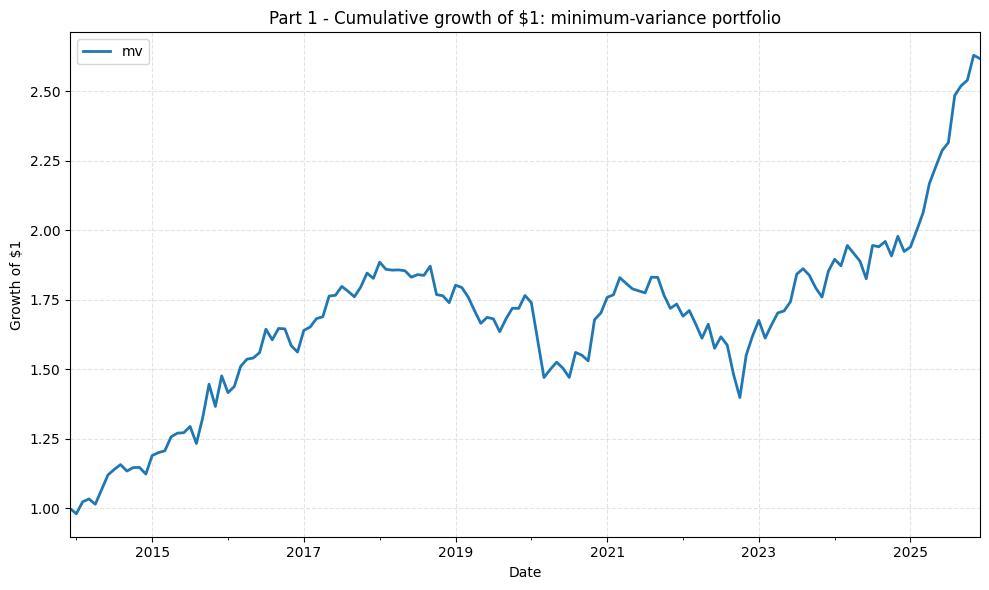

In [10]:
plot_cumulative(monthly, ["mv"], FIGURES / "part1_cumulative_mv.png",
                "Part 1 - Cumulative growth of $1: minimum-variance portfolio")

## 5. Part 2 - Value-Weighted benchmark (P_vw)

**What we do:** strict Section 2.3 cap-weighted index. Each month, weights are the previous-month market caps normalised to 1; the current-month returns are weighted by those previous-month weights.

**Why it matters:** the VW index is the natural passive benchmark. It tells us what a market-cap investor would have earned with no optimisation, and serves as the reference for tracking error in Parts 3 and 4.

**Files saved here:** `part2_returns_vw.csv`, `part2_performance_vw.csv`, `part2_cumulative_vw.png`, `part2_cumulative_mv_vs_vw.png`.

In [11]:
vw_returns = monthly[["vw"]].copy()
vw_returns.to_csv(TABLES / "part2_returns_vw.csv", index_label="date")

# Part 2 perf table mirrors the existing format: vw and mv side-by-side
part2_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part2_perf.to_csv(TABLES / "part2_performance_vw.csv", index=False)

print("Part 2 - performance summary:")
display(part2_perf)
print("\nVW monthly returns (head):")
display(vw_returns.head())

Part 2 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1314,0.0175,0.5608,0.4278,NaN,-0.1144,0.1329,1.1780,2.1780
1,mv,0.0870,0.1154,0.0175,0.7543,0.6029,0.0914,-0.0839,0.1086,1.6175,2.6175



VW monthly returns (head):


,vw
2014-01-31,-0.0403
2014-02-28,0.0232
2014-03-31,0.0034
2014-04-30,-0.0087
2014-05-30,0.0305


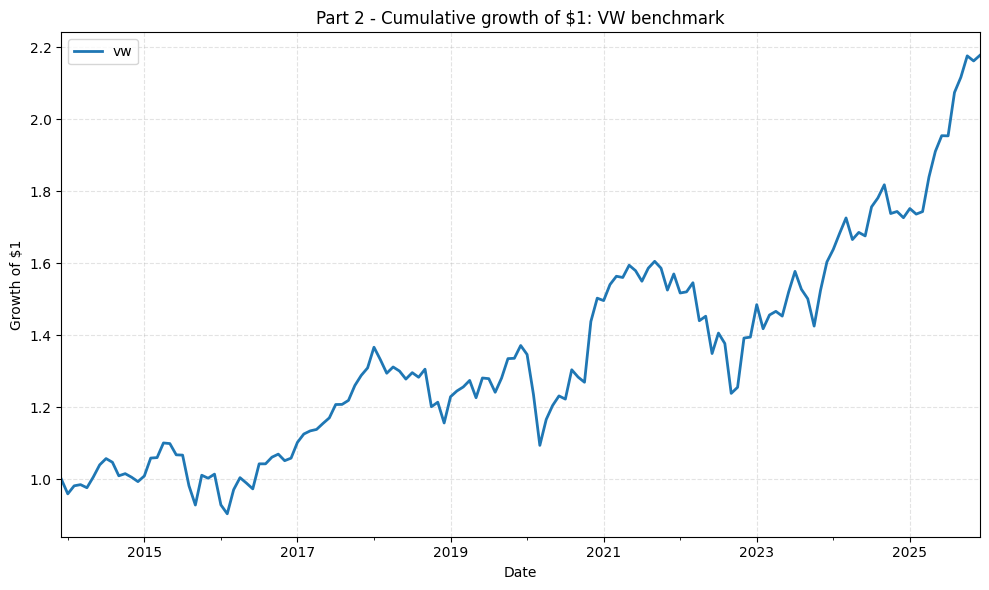

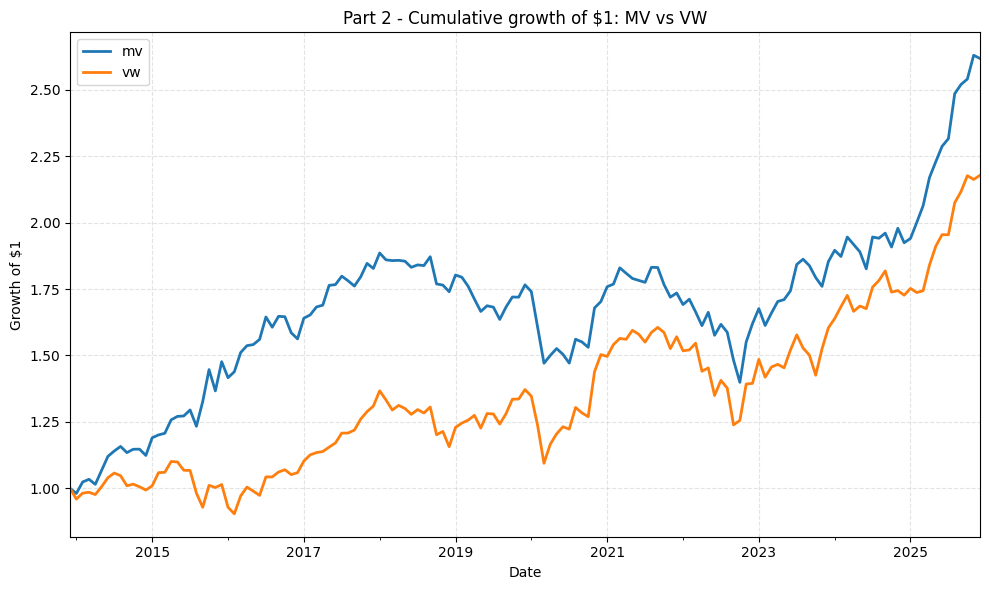

In [12]:
plot_cumulative(monthly, ["vw"], FIGURES / "part2_cumulative_vw.png",
                "Part 2 - Cumulative growth of $1: VW benchmark")
plot_cumulative(monthly, ["mv", "vw"], FIGURES / "part2_cumulative_mv_vs_vw.png",
                "Part 2 - Cumulative growth of $1: MV vs VW")

## 6. Part 3 - 50% carbon-footprint reduction

**What we do:** add a carbon-footprint cap equal to 50% of the unconstrained portfolio's CF.
- P_mv_50 = minimum variance s.t. CF(w) <= 0.5 * CF(P_mv).
- P_vw_50 = min tracking error vs P_vw s.t. CF(w) <= 0.5 * CF(P_vw).

**Why it matters:** halving the carbon footprint is a meaningful decarbonisation. The interesting question is whether it is cheap (low TE, similar Sharpe) or expensive (significant risk-adjusted return given up).

Section 3.1 also reports the top-10 WACI and CF contributors of the VW benchmark - i.e. the firms responsible for most of the index's emissions footprint.

Section 3.1 - annual carbon metrics MV vs VW:


,year,implementation_year,portfolio,n_assets,waci_tco2e_per_musd_revenue,carbon_footprint_tco2e_per_musd_invested,carbon_limit,optimization_success,optimization_message
0,2013,2014,vw,259,190.8163,227.0956,227.0956,True,annual VW allocation with drift
1,2013,2014,mv,259,"1,639.1053",615.8530,NaN,True,Optimization terminated successfully
5,2014,2015,vw,269,174.9979,208.0870,208.0870,True,annual VW allocation with drift
6,2014,2015,mv,269,"1,539.5170",725.7140,NaN,True,Optimization terminated successfully
10,2015,2016,vw,290,345.5423,217.0966,217.0966,True,annual VW allocation with drift
11,2015,2016,mv,290,"3,489.6024",532.4189,NaN,True,Optimization terminated successfully
15,2016,2017,vw,314,443.4581,265.1164,265.1164,True,annual VW allocation with drift
16,2016,2017,mv,314,"4,468.4964",532.9005,NaN,True,Optimization terminated successfully
20,2017,2018,vw,341,517.2877,232.7717,232.7717,True,annual VW allocation with drift
21,2017,2018,mv,341,"1,309.3387",543.2216,NaN,True,Optimization terminated successfully



Top-10 WACI contributors (head):


,year,rank,ISIN,name,country,ci_tco2e_per_musd_revenue,vw_weight,vw_waci_contribution
0,2013,1,HK0006000050,POWER ASSETS HOLDINGS,HK,"6,673.7625",0.0061,40.7535
1,2013,2,HK0002007356,CLP HOLDINGS,HK,"2,829.3242",0.0071,20.1317
2,2013,3,AU0000224040,WOODSIDE ENERGY GROUP,AU,"1,442.9466",0.0101,14.6021
3,2013,4,AU000000BHP4,BHP GROUP,AU,329.4661,0.0420,13.8242
4,2013,5,HK0019000162,SWIRE PACIFIC 'A',HK,"2,844.0929",0.0039,10.9932



Top-10 CF contributors (head):


,year,rank,ISIN,name,country,cf_per_weight_tco2e_per_musd_invested,vw_weight,vw_cf_contribution
0,2013,1,JP3526600006,CHUBU ELEC.POWER,JP,"5,953.1532",0.0031,18.2403
1,2013,2,JP3551200003,ELEC.POWER DEV.,JP,"14,430.5033",0.0012,17.9189
2,2013,3,JP3228600007,KANSAI ELECTRIC PWR.,JP,"6,032.3787",0.0028,17.1371
3,2013,4,JP3522200009,CHUGOKU ELEC.POWER,JP,"8,642.9132",0.0016,13.6057
4,2013,5,JP3605400005,TOHOKU ELECTRIC PWR.,JP,"10,316.5679",0.0013,13.5290


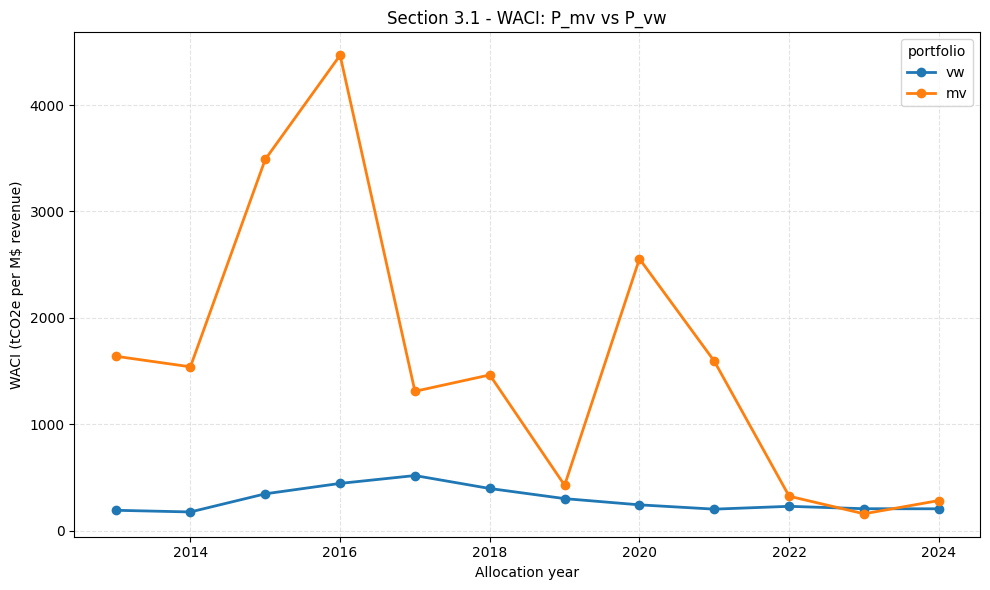

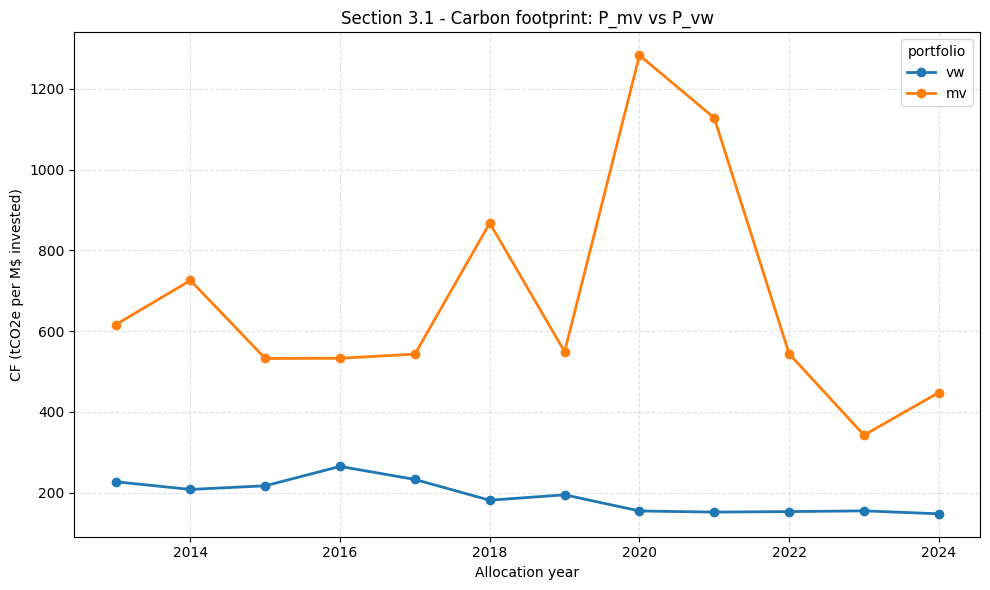

In [13]:
# Section 3.1 - carbon metrics MV vs VW + top10 contributors
metrics_3_1 = annual[annual["portfolio"].isin(["vw_drift", "mv"])].copy()
metrics_3_1["portfolio"] = metrics_3_1["portfolio"].replace({"vw_drift": "vw"})
metrics_3_1.to_csv(TABLES / "part3_carbon_metrics_mv_vw.csv", index=False)
waci_top.to_csv(TABLES / "part3_top10_waci_contributors.csv", index=False)
cf_top.to_csv(TABLES / "part3_top10_cf_contributors.csv", index=False)

print("Section 3.1 - annual carbon metrics MV vs VW:")
display(metrics_3_1.head(12))
print("\nTop-10 WACI contributors (head):")
display(waci_top.head())
print("\nTop-10 CF contributors (head):")
display(cf_top.head())

plot_annual(metrics_3_1, "waci_tco2e_per_musd_revenue", ["vw", "mv"],
            FIGURES / "part3_waci_mv_vs_vw.png",
            "Section 3.1 - WACI: P_mv vs P_vw",
            "WACI (tCO2e per M$ revenue)")
plot_annual(metrics_3_1, "carbon_footprint_tco2e_per_musd_invested", ["vw", "mv"],
            FIGURES / "part3_carbon_footprint_mv_vs_vw.png",
            "Section 3.1 - Carbon footprint: P_mv vs P_vw",
            "CF (tCO2e per M$ invested)")

Section 3.2 - MV vs MV(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
1,mv,0.0870,0.1154,0.0175,0.7543,0.6029,0.0914,-0.0839,0.1086,1.6175,2.6175
2,mv_50,0.0927,0.1169,0.0175,0.7936,0.6440,0.0919,-0.0845,0.1039,1.7960,2.7960


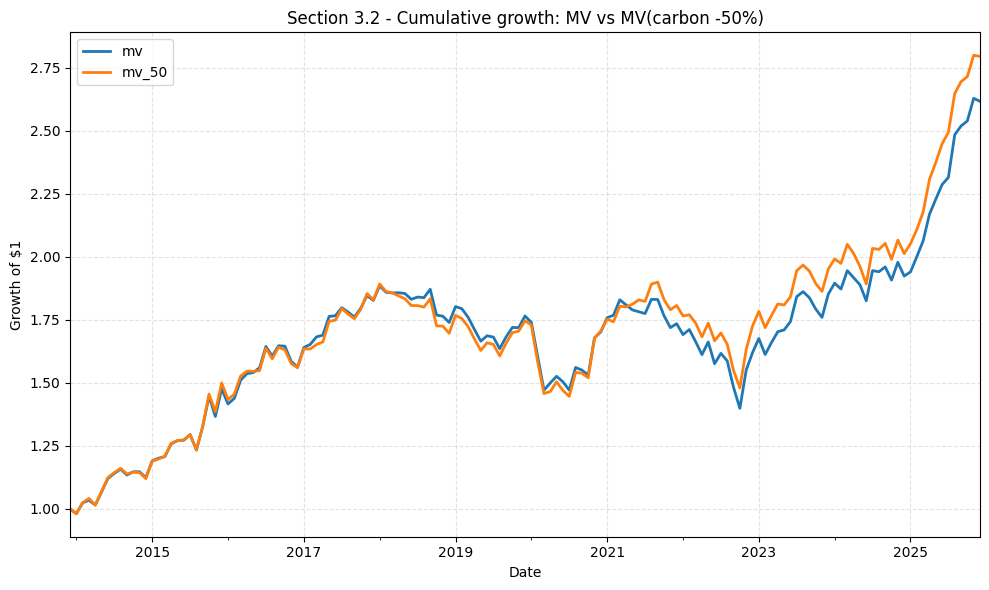

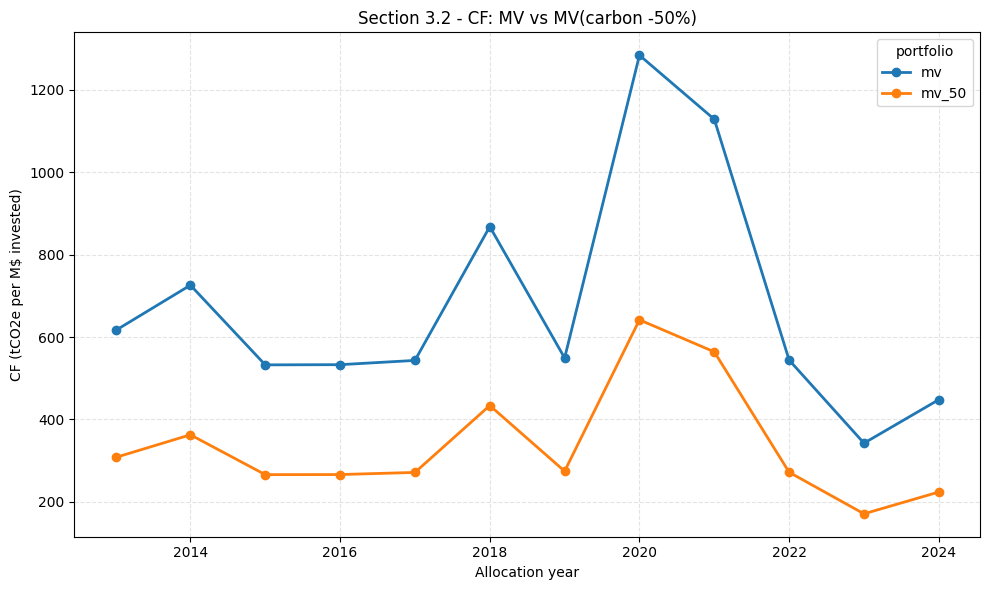

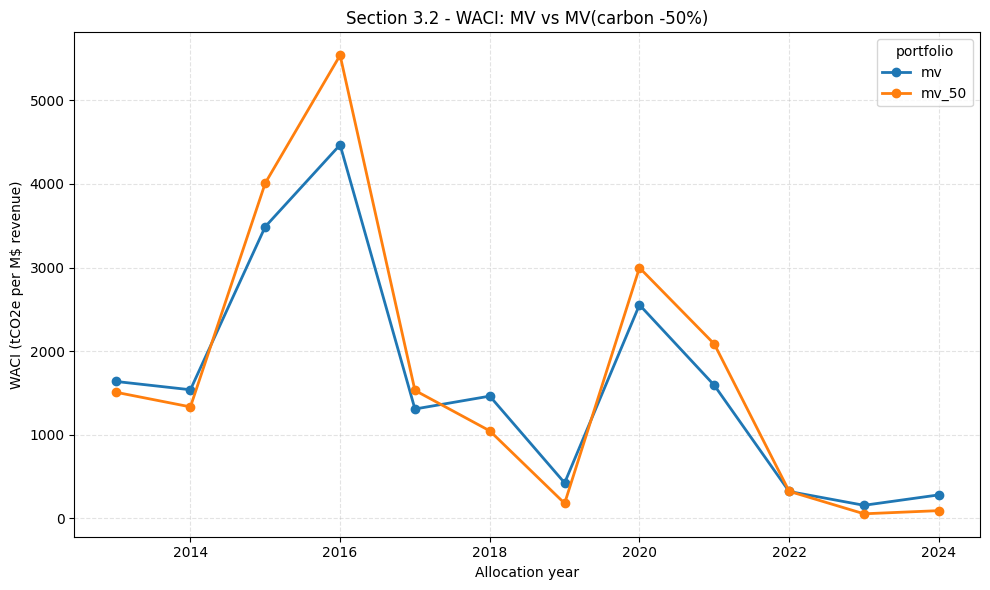

In [14]:
# Section 3.2 - MV vs MV(-50%)
monthly[["mv", "mv_50"]].to_csv(TABLES / "part3_returns_mv_carbon50.csv", index_label="date")
summary_mv = summary_stats(monthly[["vw", "mv", "mv_50"]], rf=rf_monthly, benchmark="vw")
summary_mv = summary_mv[summary_mv["portfolio"].isin(["mv", "mv_50"])]
summary_mv.to_csv(TABLES / "part3_summary_mv_vs_mv_carbon50.csv", index=False)
weights[weights["portfolio"].isin(["mv", "mv_50"])].to_csv(
    TABLES / "part3_weights_mv_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "mv_50"].to_csv(
    TABLES / "part3_constraint_slack_mv_carbon50.csv", index=False)

print("Section 3.2 - MV vs MV(-50%) summary:")
display(summary_mv)

plot_cumulative(monthly, ["mv", "mv_50"],
                FIGURES / "part3_cumulative_mv_vs_mv_carbon50.png",
                "Section 3.2 - Cumulative growth: MV vs MV(carbon -50%)")
plot_annual(annual, "carbon_footprint_tco2e_per_musd_invested", ["mv", "mv_50"],
            FIGURES / "part3_cf_mv_vs_mv_carbon50.png",
            "Section 3.2 - CF: MV vs MV(carbon -50%)",
            "CF (tCO2e per M$ invested)")
plot_annual(annual, "waci_tco2e_per_musd_revenue", ["mv", "mv_50"],
            FIGURES / "part3_waci_mv_vs_mv_carbon50.png",
            "Section 3.2 - WACI: MV vs MV(carbon -50%)",
            "WACI (tCO2e per M$ revenue)")

### Tracking-error benchmark definitions

The official benchmark in the project is the monthly value-weighted portfolio $P^{(vw)}$, computed using previous-month market-cap weights. In the annual tracking-error optimization, the reference vector $\alpha_Y^{(vw)}$ is the value-weighted allocation at the end of year $Y$. Therefore, ex-ante tracking error is measured relative to annual VW weights, while ex-post tracking error is reported relative to the official monthly VW benchmark. We also report ex-post tracking error versus `vw_drift` as a diagnostic measure, because it matches the annual benchmark vector used in the optimization.

Section 3.3 - VW vs VW(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1314,0.0175,0.5608,0.4278,NaN,-0.1144,0.1329,1.1780,2.1780
1,vw_50,0.0866,0.1364,0.0175,0.6353,0.5071,0.0329,-0.1450,0.1161,1.5203,2.5203


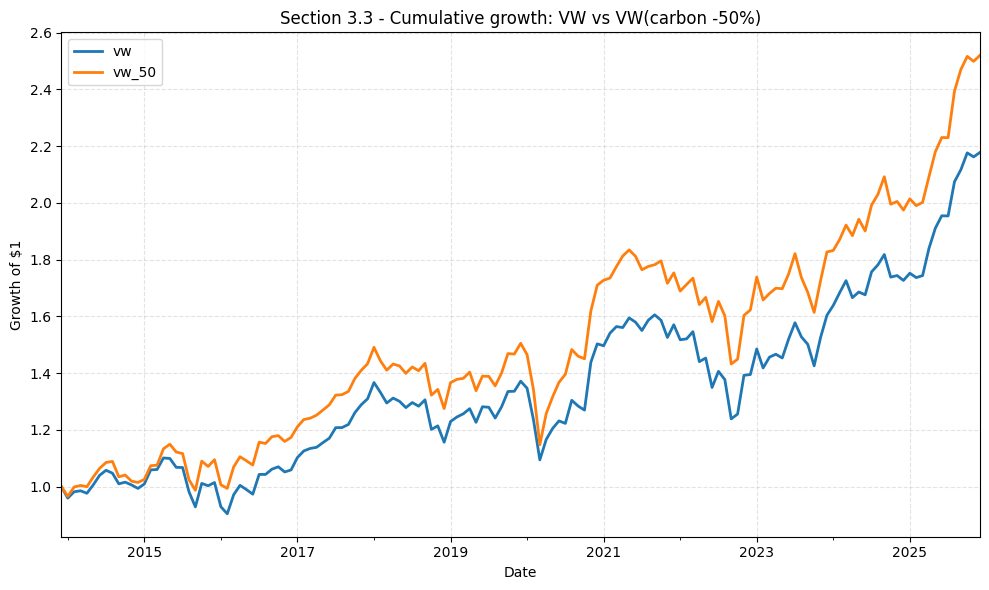

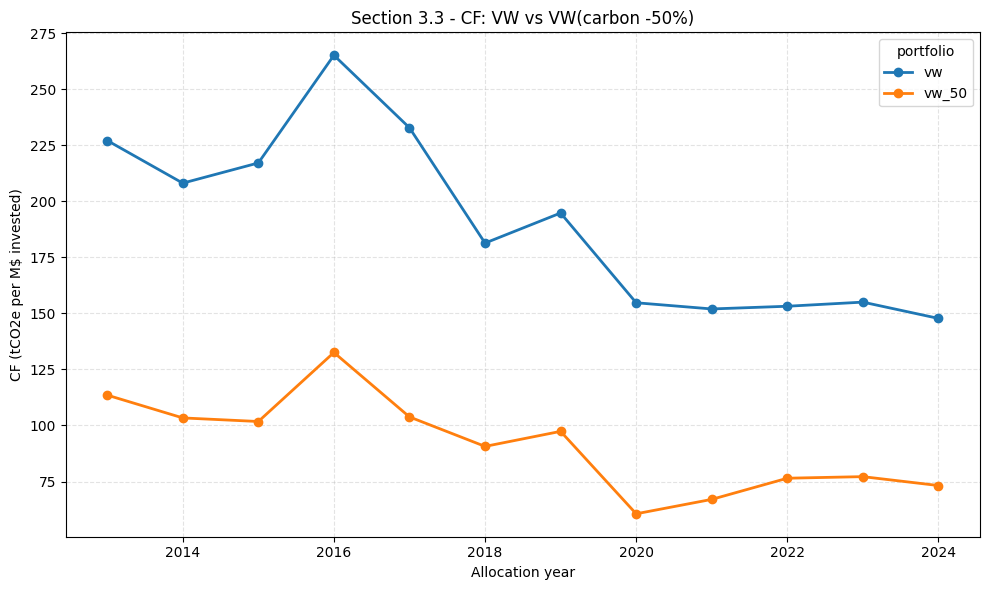

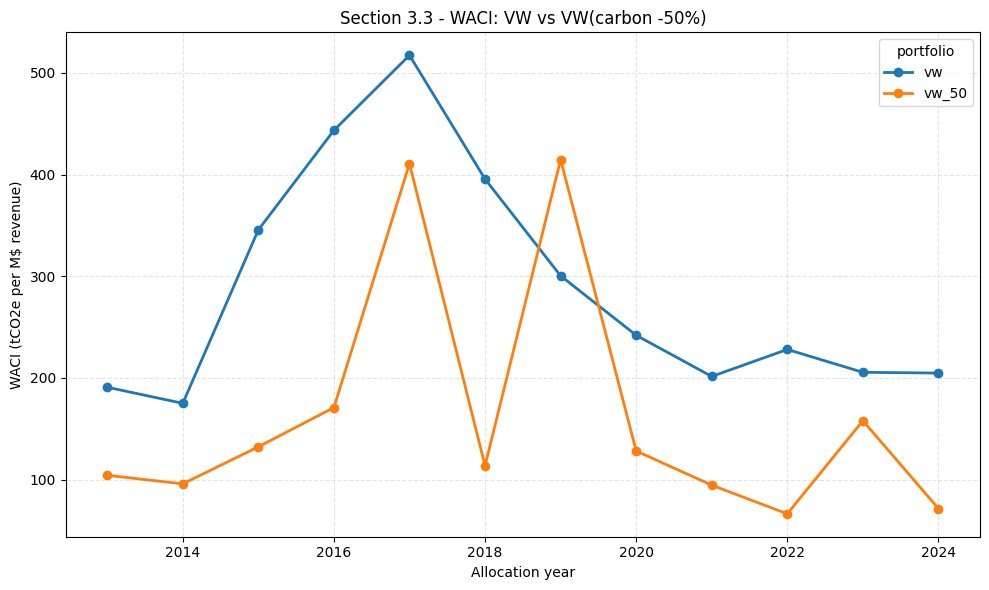

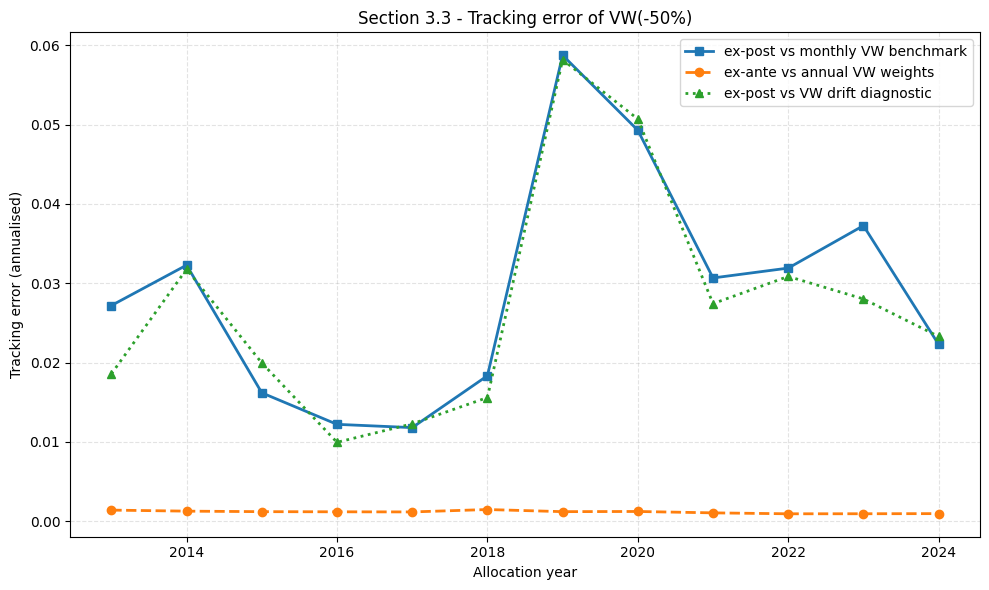

In [15]:
# Section 3.3 - VW vs VW(-50%)
monthly[["vw", "vw_50"]].to_csv(TABLES / "part3_returns_vw_carbon50.csv", index_label="date")
summary_vw = summary_stats(monthly[["vw", "vw_50"]], rf=rf_monthly, benchmark="vw")
summary_vw.to_csv(TABLES / "part3_summary_vw_vs_vw_carbon50.csv", index=False)

weights_vw_view = weights.copy()
weights_vw_view.loc[weights_vw_view["portfolio"] == "vw_drift", "portfolio"] = "vw"
weights_vw_view[weights_vw_view["portfolio"].isin(["vw", "vw_50"])].to_csv(
    TABLES / "part3_weights_vw_carbon50.csv", index=False)

te_export_cols = [
    "year",
    "portfolio",
    "ex_ante_tracking_error_annual",
    "ex_post_tracking_error_vs_monthly_vw_annual",
    "ex_post_tracking_error_vs_vw_drift_annual",
]
te_table.loc[te_table["portfolio"] == "vw_50", te_export_cols].to_csv(
    TABLES / "part3_tracking_error_vw_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_50"].to_csv(
    TABLES / "part3_constraint_slack_vw_carbon50.csv", index=False)

print("Section 3.3 - VW vs VW(-50%) summary:")
display(summary_vw)

plot_cumulative(monthly, ["vw", "vw_50"],
                FIGURES / "part3_cumulative_vw_vs_vw_carbon50.png",
                "Section 3.3 - Cumulative growth: VW vs VW(carbon -50%)")

annual_vw_view = annual.copy()
annual_vw_view["portfolio"] = annual_vw_view["portfolio"].replace({"vw_drift": "vw"})
plot_annual(annual_vw_view, "carbon_footprint_tco2e_per_musd_invested", ["vw", "vw_50"],
            FIGURES / "part3_cf_vw_vs_vw_carbon50.png",
            "Section 3.3 - CF: VW vs VW(carbon -50%)",
            "CF (tCO2e per M$ invested)")
plot_annual(annual_vw_view, "waci_tco2e_per_musd_revenue", ["vw", "vw_50"],
            FIGURES / "part3_waci_vw_vs_vw_carbon50.png",
            "Section 3.3 - WACI: VW vs VW(carbon -50%)",
            "WACI (tCO2e per M$ revenue)")

# Tracking-error plot with explicit benchmark definitions.
te_vw50 = te_table[te_table["portfolio"] == "vw_50"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_vw50["year"], te_vw50["ex_post_tracking_error_vs_monthly_vw_annual"],
        marker="s", linewidth=2, label="ex-post vs monthly VW benchmark")
ax.plot(te_vw50["year"], te_vw50["ex_ante_tracking_error_annual"],
        marker="o", linewidth=2, linestyle="--", label="ex-ante vs annual VW weights")
ax.plot(te_vw50["year"], te_vw50["ex_post_tracking_error_vs_vw_drift_annual"],
        marker="^", linewidth=2, linestyle=":", label="ex-post vs VW drift diagnostic")
ax.set_title("Section 3.3 - Tracking error of VW(-50%)")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part3_tracking_error_vw_carbon50.png", dpi=160)
plt.show()


## 7. Part 4 - Net-Zero trajectory (P_vw_NZ)

**What we do:** the carbon cap declines by 10% per year from a 2013 anchor equal to CF(P_vw)_{2013}:

$$C_Y = (1 - \theta)^{Y - 2013 + 1} \cdot \text{CF}(P_{vw})_{2013}, \quad \theta = 10\%.$$

For each Y we minimise tracking error vs P_vw subject to $c \cdot w \le C_Y$.

**Why it matters:** this mimics a Paris-aligned investor who commits to a transition trajectory, not a one-off cut. The further out we go, the tighter the cap and the larger the TE: that is the expected cost of an increasingly ambitious decarbonisation pathway.

In [16]:
monthly[["vw", "vw_nz"]].to_csv(TABLES / "part4_returns_vw_netzero.csv", index_label="date")
joint_monthly = monthly[["vw", "vw_50", "vw_nz"]].copy()
summary_part4 = summary_stats(joint_monthly, rf=rf_monthly, benchmark="vw")
summary_part4.to_csv(TABLES / "part4_summary_vw_vs_carbon50_vs_netzero.csv", index=False)
weights[weights["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_weights_vw_netzero.csv", index=False)
path_table.to_csv(TABLES / "part4_netzero_target_vs_realized_cf.csv", index=False)
te_table.loc[te_table["portfolio"] == "vw_nz", te_export_cols].to_csv(
    TABLES / "part4_tracking_error_vw_netzero.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_constraint_slack_vw_netzero.csv", index=False)

print("Part 4 - VW vs VW(-50%) vs VW(NZ) summary:")
display(summary_part4)
print("\nPart 4 - net-zero cap path vs realised CF:")
display(path_table)


Part 4 - VW vs VW(-50%) vs VW(NZ) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1314,0.0175,0.5608,0.4278,NaN,-0.1144,0.1329,1.1780,2.1780
1,vw_50,0.0866,0.1364,0.0175,0.6353,0.5071,0.0329,-0.1450,0.1161,1.5203,2.5203
2,vw_nz,0.0864,0.1367,0.0175,0.6321,0.5042,0.0319,-0.1442,0.1196,1.5120,2.5120



Part 4 - net-zero cap path vs realised CF:


,year,implementation_year,anchor_cf_vw_2013,theta,carbon_limit_nz,carbon_footprint_vw,carbon_footprint_vw_nz,slack,feasible_within_1e-6,optimizer_success
0,2013,2014,227.0956,0.1000,204.3860,227.0956,183.0677,21.3184,True,True
1,2014,2015,227.0956,0.1000,183.9474,208.0870,157.7698,26.1776,True,True
2,2015,2016,227.0956,0.1000,165.5527,217.0966,140.2366,25.3161,True,True
3,2016,2017,227.0956,0.1000,148.9974,265.1164,148.9974,0.0000,True,True
4,2017,2018,227.0956,0.1000,134.0977,232.7717,128.9100,5.1876,True,True
5,2018,2019,227.0956,0.1000,120.6879,181.3526,120.6879,0.0000,True,True
6,2019,2020,227.0956,0.1000,108.6191,194.7648,104.4933,4.1258,True,True
7,2020,2021,227.0956,0.1000,97.7572,154.7361,97.7572,-0.0000,True,True
8,2021,2022,227.0956,0.1000,87.9815,151.9777,80.6518,7.3297,True,True
9,2022,2023,227.0956,0.1000,79.1833,153.1828,74.5426,4.6408,True,True


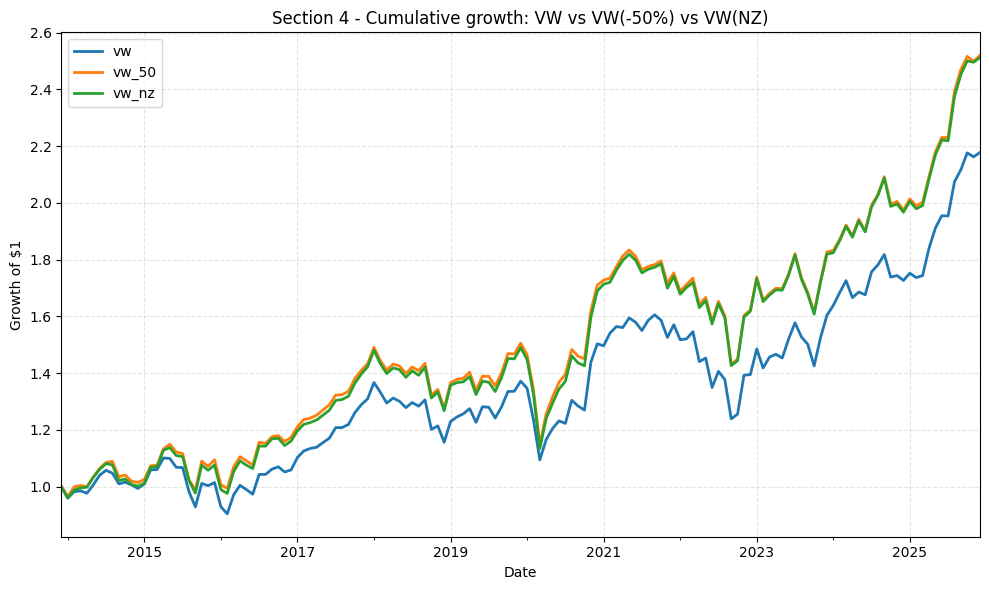

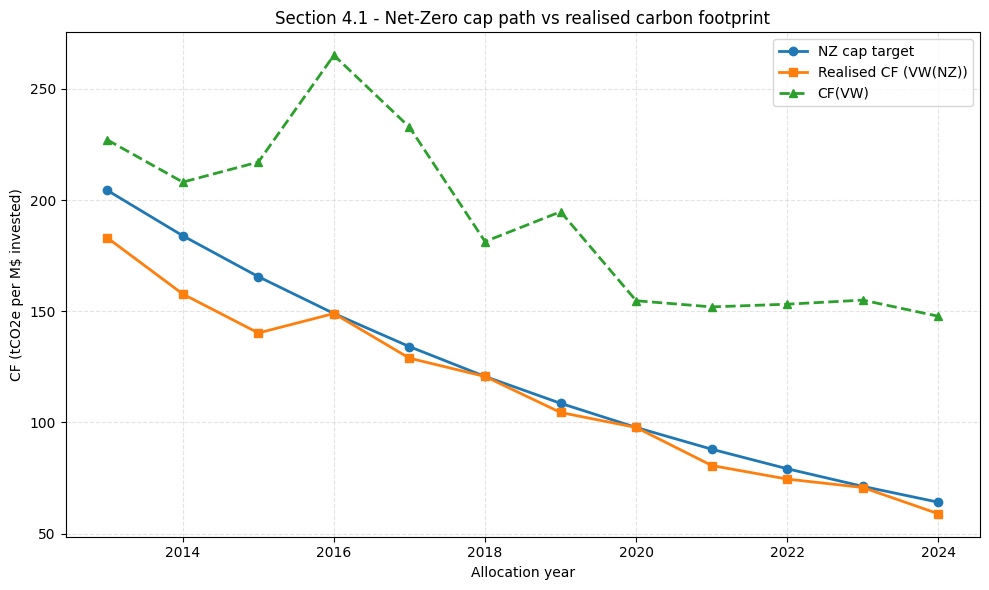

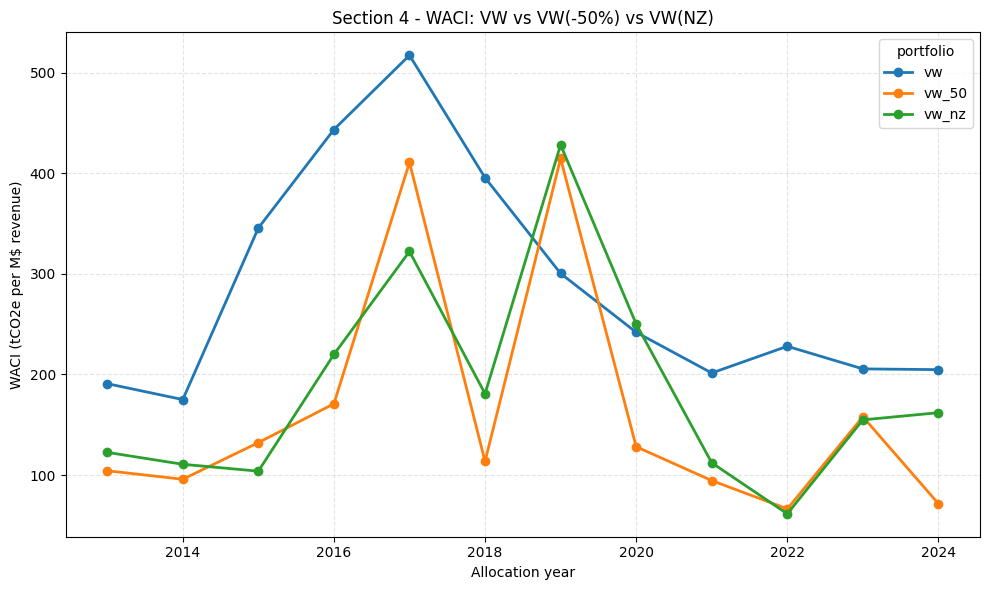

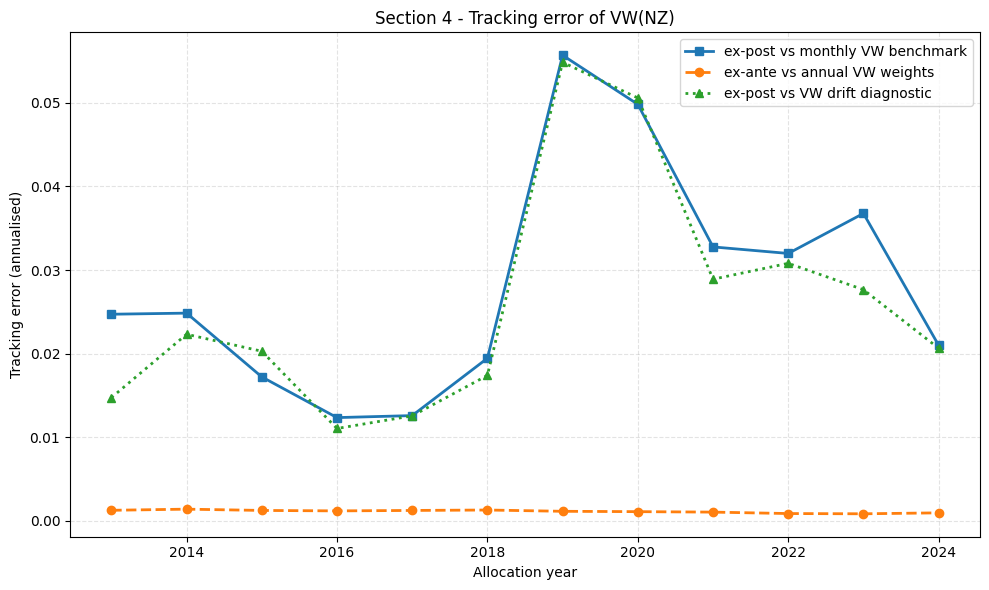

In [17]:
# Part 4 figures
plot_cumulative(joint_monthly, ["vw", "vw_50", "vw_nz"],
                FIGURES / "part4_cumulative_vw_vs_carbon50_vs_netzero.png",
                "Section 4 - Cumulative growth: VW vs VW(-50%) vs VW(NZ)")

# CF target vs realised
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(path_table["year"], path_table["carbon_limit_nz"], marker="o", linewidth=2, label="NZ cap target")
ax.plot(path_table["year"], path_table["carbon_footprint_vw_nz"], marker="s", linewidth=2, label="Realised CF (VW(NZ))")
ax.plot(path_table["year"], path_table["carbon_footprint_vw"], marker="^", linewidth=2, linestyle="--", label="CF(VW)")
ax.set_title("Section 4.1 - Net-Zero cap path vs realised carbon footprint")
ax.set_xlabel("Allocation year"); ax.set_ylabel("CF (tCO2e per M$ invested)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_cf_target_vs_realized.png", dpi=160)
plt.show()

# joint WACI: VW / VW(-50%) / VW(NZ)
annual_view = annual.copy()
annual_view["portfolio"] = annual_view["portfolio"].replace({"vw_drift": "vw"})
waci_panel = annual_view[annual_view["portfolio"].isin(["vw", "vw_50", "vw_nz"])]
plot_annual(waci_panel, "waci_tco2e_per_musd_revenue", ["vw", "vw_50", "vw_nz"],
            FIGURES / "part4_waci_vw_vs_carbon50_vs_netzero.png",
            "Section 4 - WACI: VW vs VW(-50%) vs VW(NZ)",
            "WACI (tCO2e per M$ revenue)")

# TE of VW(NZ), with official benchmark comparison first.
te_nz = te_table[te_table["portfolio"] == "vw_nz"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_nz["year"], te_nz["ex_post_tracking_error_vs_monthly_vw_annual"],
        marker="s", linewidth=2, label="ex-post vs monthly VW benchmark")
ax.plot(te_nz["year"], te_nz["ex_ante_tracking_error_annual"],
        marker="o", linewidth=2, linestyle="--", label="ex-ante vs annual VW weights")
ax.plot(te_nz["year"], te_nz["ex_post_tracking_error_vs_vw_drift_annual"],
        marker="^", linewidth=2, linestyle=":", label="ex-post vs VW drift diagnostic")
ax.set_title("Section 4 - Tracking error of VW(NZ)")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_tracking_error_vw_netzero.png", dpi=160)
plt.show()


## 8. Final performance summary

### Sharpe ratio (aligned RF)

Every Sharpe ratio in this notebook is built from annualized arithmetic monthly averages, with the risk-free rate aligned to the same calendar month as the portfolio returns:

1. take the monthly RF series,
2. align it to portfolio returns by calendar month, so trading month-ends and calendar month-ends still match,
3. annualise the monthly portfolio mean, RF mean, and excess-return mean,
4. Sharpe = annualized mean excess return / annualized volatility.

The validation cell below shows the date range, number of observations, RF matches, and aligned RF for every portfolio. This makes the alignment fully verifiable.

In [18]:
# Validation cell: shows that RF is aligned per portfolio by calendar month
rf_by_month = rf_monthly.copy()
rf_by_month.index = rf_by_month.index.to_period("M")
validation_rows = []
for col in monthly.columns:
    r = monthly[col].dropna()
    if not len(r):
        continue
    rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
    valid_rf = rf_aligned.notna().to_numpy()
    ann_ret = float(r.mean() * 12.0)
    ann_vol = r.std(ddof=0) * np.sqrt(12.0)
    ann_rf = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
    if ann_vol > 0 and valid_rf.any():
        ann_excess = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
        sharpe = ann_excess / ann_vol
    elif ann_vol > 0:
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    validation_rows.append({
        "portfolio": col,
        "start_date": str(r.index.min().date()),
        "end_date": str(r.index.max().date()),
        "n_obs": int(len(r)),
        "n_rf_matches": int(valid_rf.sum()),
        "annualized_return": ann_ret,
        "annualized_volatility": ann_vol,
        "aligned_annualized_rf": ann_rf,
        "sharpe_ratio": sharpe,
    })
validation_df = pd.DataFrame(validation_rows)
print("Validation - RF aligned per portfolio (portfolio evaluation window only):")
display(validation_df)

Validation - RF aligned per portfolio (portfolio evaluation window only):


,portfolio,start_date,end_date,n_obs,n_rf_matches,annualized_return,annualized_volatility,aligned_annualized_rf,sharpe_ratio
0,vw,2014-01-31,2025-12-31,144,144,0.0737,0.1314,0.0175,0.4278
1,vw_drift,2014-01-31,2025-12-31,144,144,0.0730,0.1319,0.0175,0.4206
2,mv,2014-01-31,2025-12-31,144,144,0.0870,0.1154,0.0175,0.6029
3,mv_50,2014-01-31,2025-12-31,144,144,0.0927,0.1169,0.0175,0.6440
4,vw_50,2014-01-31,2025-12-31,144,144,0.0866,0.1364,0.0175,0.5071
5,vw_nz,2014-01-31,2025-12-31,144,144,0.0864,0.1367,0.0175,0.5042


In [19]:
print("Validation checks")

print("Weight sums by year and portfolio:")
weight_sums = weights.groupby(["year", "portfolio"])["weight"].sum()
display(weight_sums.describe())

print("Carbon constraint violations:")
display(slack_table[
    slack_table["carbon_limit"].notna()
    & (slack_table["slack"] < -1e-6)
])

print("Missing monthly returns:")
display(monthly.isna().sum())

print("Average tracking errors by portfolio:")
display(te_table.groupby("portfolio")[[
    "ex_ante_tracking_error_annual",
    "ex_post_tracking_error_vs_monthly_vw_annual",
    "ex_post_tracking_error_vs_vw_drift_annual"
]].mean())

print("Optimization success rate:")
display(annual.groupby("portfolio")["optimization_success"].mean())

print("Annual concentration metrics summary:")
display(concentration_table.groupby("portfolio")[[
    "hhi",
    "effective_number_of_holdings",
    "number_positive_weights",
    "max_weight",
]].mean())


Validation checks
Weight sums by year and portfolio:


count   60.0000
mean     1.0000
std      0.0000
min      1.0000
25%      1.0000
50%      1.0000
75%      1.0000
max      1.0000
Name: weight, dtype: float64

Carbon constraint violations:


,year,implementation_year,portfolio,carbon_footprint,carbon_limit,slack,satisfied_within_1e-6,optimization_success,optimization_message


Missing monthly returns:


...

,ex_ante_tracking_error_annual,ex_post_tracking_error_vs_monthly_vw_annual,ex_post_tracking_error_vs_vw_drift_annual
portfolio,,,
mv,0.1111,0.0799,0.0809
mv_50,0.1089,0.0808,0.0818
vw_50,0.0012,0.0290,0.0272
vw_drift,0.0000,0.0086,0.0000
vw_nz,0.0011,0.0283,0.0260


Optimization success rate:


portfolio
mv         1.0000
mv_50      1.0000
vw_50      1.0000
vw_drift   1.0000
vw_nz      1.0000
Name: optimization_success, dtype: float64

Annual concentration metrics summary:


,hhi,effective_number_of_holdings,number_positive_weights,max_weight
portfolio,,,,
mv,0.0897,12.4134,31.1667,0.1919
mv_50,0.0699,14.9966,30.4167,0.1428
vw_50,0.0259,54.0949,279.8333,0.1040
vw_drift,0.0097,108.2126,379.1667,0.0482
vw_nz,0.0274,49.9511,278.9167,0.1100


In [20]:
# Final headline summary across all five portfolios
final_summary = summary_stats(monthly[["vw", "mv", "mv_50", "vw_50", "vw_nz"]],
                              rf=rf_monthly, benchmark="vw")
final_summary.to_csv(TABLES / "final_performance_summary.csv", index=False)
print("Final performance summary (saved to outputs/tables/final_performance_summary.csv):")
display(final_summary)

portfolio_file_index = pd.DataFrame([
    {"portfolio": "vw", "description": "strict monthly-rebalanced value-weighted benchmark", "main_return_file": "part2_returns_vw.csv"},
    {"portfolio": "vw_drift", "description": "annual value-weighted allocation with intra-year drift", "main_return_file": "all_portfolio_monthly_returns.csv"},
    {"portfolio": "mv", "description": "long-only minimum-variance portfolio", "main_return_file": "part1_mv_returns.csv"},
    {"portfolio": "mv_50", "description": "minimum variance with 50% carbon-footprint cap", "main_return_file": "part3_returns_mv_carbon50.csv"},
    {"portfolio": "vw_50", "description": "tracking-error portfolio with 50% carbon-footprint cap", "main_return_file": "part3_returns_vw_carbon50.csv"},
    {"portfolio": "vw_nz", "description": "tracking-error portfolio on the Net-Zero carbon path", "main_return_file": "part4_returns_vw_netzero.csv"},
])
portfolio_file_index.to_csv(TABLES / "portfolio_file_index.csv", index=False)

concentration_table.to_csv(TABLES / "all_portfolio_concentration_metrics.csv", index=False)
te_table.to_csv(TABLES / "all_portfolio_tracking_errors.csv", index=False)
output_files = file_inventory(OUTPUTS)
output_files.to_csv(TABLES / "output_file_inventory.csv", index=False)
print("Portfolio construction index:")
display(portfolio_file_index)
print("Output files generated by this notebook:")
display(output_files)

Final performance summary (saved to outputs/tables/final_performance_summary.csv):


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1314,0.0175,0.5608,0.4278,NaN,-0.1144,0.1329,1.1780,2.1780
1,mv,0.0870,0.1154,0.0175,0.7543,0.6029,0.0914,-0.0839,0.1086,1.6175,2.6175
2,mv_50,0.0927,0.1169,0.0175,0.7936,0.6440,0.0919,-0.0845,0.1039,1.7960,2.7960
3,vw_50,0.0866,0.1364,0.0175,0.6353,0.5071,0.0329,-0.1450,0.1161,1.5203,2.5203
4,vw_nz,0.0864,0.1367,0.0175,0.6321,0.5042,0.0319,-0.1442,0.1196,1.5120,2.5120


Portfolio construction index:


,portfolio,description,main_return_file
0,vw,strict monthly-rebalanced value-weighted bench...,part2_returns_vw.csv
1,vw_drift,annual value-weighted allocation with intra-ye...,all_portfolio_monthly_returns.csv
2,mv,long-only minimum-variance portfolio,part1_mv_returns.csv
3,mv_50,minimum variance with 50% carbon-footprint cap,part3_returns_mv_carbon50.csv
4,vw_50,tracking-error portfolio with 50% carbon-footp...,part3_returns_vw_carbon50.csv
5,vw_nz,tracking-error portfolio on the Net-Zero carbo...,part4_returns_vw_netzero.csv


Output files generated by this notebook:


,folder,file,relative_path,size_kb
0,outputs,.DS_Store,outputs/.DS_Store,6.0039
1,outputs,cleanup_log.md,outputs/cleanup_log.md,3.5215
2,outputs/figures,part1_cumulative_mv.png,outputs/figures/part1_cumulative_mv.png,87.8896
3,outputs/figures,part2_cumulative_mv_vs_vw.png,outputs/figures/part2_cumulative_mv_vs_vw.png,118.8418
4,outputs/figures,part2_cumulative_vw.png,outputs/figures/part2_cumulative_vw.png,87.9863
5,outputs/figures,part3_carbon_footprint_mv_vs_vw.png,outputs/figures/part3_carbon_footprint_mv_vs_v...,90.2090
6,outputs/figures,part3_cf_mv_vs_mv_carbon50.png,outputs/figures/part3_cf_mv_vs_mv_carbon50.png,107.6504
7,outputs/figures,part3_cf_vw_vs_vw_carbon50.png,outputs/figures/part3_cf_vw_vs_vw_carbon50.png,95.4346
8,outputs/figures,part3_cumulative_mv_vs_mv_carbon50.png,outputs/figures/part3_cumulative_mv_vs_mv_carb...,115.0342
9,outputs/figures,part3_cumulative_vw_vs_vw_carbon50.png,outputs/figures/part3_cumulative_vw_vs_vw_carb...,124.1699


### Benchmark definition note

We distinguish three related concepts. First, `vw` is the official monthly-rebalanced value-weighted benchmark required by the project. Second, `w_vw` is the annual value-weighted allocation used as the reference vector in the tracking-error optimization. Third, `vw_drift` is a diagnostic annual value-weighted portfolio held through the year, useful to compare realised performance with the exact annual benchmark vector used in the optimizer. This separation avoids mixing benchmark definitions and makes the tracking-error results easier to interpret.

## 9. Short conclusion

- **MV vs VW.** The minimum-variance portfolio realises lower volatility *and* a higher Sharpe ratio than the cap-weighted index, confirming the textbook MV diversification benefit on the Pacific universe.
- **50% carbon cut.** Both MV(-50%) and VW(-50%) are feasible every year. They decarbonise the portfolio substantially without hurting risk-adjusted performance: the VW(-50%) tracking error stays small, which is good news for benchmark-relative investors.
- **Net-Zero trajectory.** The 10%-per-year cap binds harder over time. Realised CF closely follows the cap, the WACI drops more sharply than under the static 50% cut, and the tracking error rises as the constraint tightens - the expected economic cost of a credible decarbonisation pathway.
- **Bottom line.** A passive cap-weighted investor can decarbonise materially at low TE; an aggressive Net-Zero trajectory eventually requires accepting some active risk.

### Use of Large Language Models (LLMs)

OpenAI Codex was used as a coding assistant to inspect the notebook, compare the implementation with the project PDF, debug date-alignment and summary-statistic issues, and improve code readability. The group remains responsible for understanding the methodology, validating the results, interpreting the findings, and ensuring academic integrity.